In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

PART 2: DATA EXPLORATION - Generate Synthetic ADR Dataset

In [3]:
np.random.seed(42)
n = 1000

age = np.random.randint(1, 90, n)
gender = np.random.choice(['Male', 'Female', 'Unknown'], n, p=[0.48, 0.48, 0.04])
drug_form = np.random.choice(['Tablet', 'Capsule', 'Injection', 'Syrup', 'Patch'], n)
country = np.random.choice(['USA', 'India', 'UK', 'Germany', 'France'], n)
hospitalized = np.random.choice([0, 1], n, p=[0.6, 0.4])
death = np.random.choice([0, 1], n, p=[0.9, 0.1])
reaction_count = np.random.randint(1, 10, n)
weight = np.random.uniform(40, 120, n).round(1)
weight[np.random.choice(n, 80, replace=False)] = np.nan  # Add missing values

# Target: ADR Severity (0=Mild, 1=Moderate, 2=Severe)
severity = []
for i in range(n):
    if hospitalized[i] == 1 or death[i] == 1:
        severity.append(2)
    elif reaction_count[i] > 5:
        severity.append(1)
    else:
        severity.append(0)

df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'drug_form': drug_form,
    'country': country,
    'hospitalized': hospitalized,
    'death': death,
    'reaction_count': reaction_count,
    'weight': weight,
    'severity': severity
})

# Add some extra noise columns to clean later
df['useless_id'] = range(n)
df['notes'] = np.nan

print("=== First 10 Rows ===")
print(df.head(10))
print("\n=== Shape ===", df.shape)
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Summary Statistics ===")
print(df.describe())
print("\n=== Unique Values Per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
print("\n=== Categorical Columns ===", df.select_dtypes('object').columns.tolist())
print("=== Numerical Columns ===", df.select_dtypes('number').columns.tolist())

=== First 10 Rows ===
   age  gender  drug_form  country  hospitalized  death  reaction_count  \
0   52  Female      Patch    India             1      0               5   
1   15  Female      Patch    India             1      1               8   
2   72  Female      Patch      USA             1      0               7   
3   61    Male    Capsule       UK             0      0               4   
4   21  Female  Injection      USA             0      1               4   
5   83    Male      Patch  Germany             1      0               6   
6   87    Male      Patch      USA             0      0               6   
7   75  Female    Capsule   France             0      0               9   
8   75    Male    Capsule      USA             1      0               5   
9   88    Male      Patch   France             1      0               8   

   weight  severity  useless_id  notes  
0    79.9         2           0    NaN  
1    48.8         2           1    NaN  
2    71.2         2          

PART 3: DATA CLEANING

In [4]:
# Remove unnecessary columns
df.drop(columns=['useless_id', 'notes'], inplace=True)

# Fill missing weight with median
df['weight'].fillna(df['weight'].median(), inplace=True)

# Convert object columns to category
for col in ['gender', 'drug_form', 'country']:
    df[col] = df[col].astype('category')

# Standardize drug form names (strip and title case)
df['drug_form'] = df['drug_form'].str.strip().str.title()

# Create age groups
def age_group(a):
    if a < 18: return 'Child'
    elif a < 40: return 'Young Adult'
    elif a < 60: return 'Middle Aged'
    else: return 'Senior'

df['age_group'] = df['age'].apply(age_group).astype('category')

# Binary columns already 0/1 (hospitalized, death)
# Encode categorical columns for modeling
le = LabelEncoder()
df['gender_enc'] = le.fit_transform(df['gender'])
df['drug_form_enc'] = le.fit_transform(df['drug_form'])
df['country_enc'] = le.fit_transform(df['country'])
df['age_group_enc'] = le.fit_transform(df['age_group'])

print("Cleaned dataset shape:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())
print("\nSample cleaned data:")
print(df.head())

Cleaned dataset shape: (1000, 14)
Missing values after cleaning:
 age               0
gender            0
drug_form         0
country           0
hospitalized      0
death             0
reaction_count    0
weight            0
severity          0
age_group         0
gender_enc        0
drug_form_enc     0
country_enc       0
age_group_enc     0
dtype: int64

Sample cleaned data:
   age  gender  drug_form country  hospitalized  death  reaction_count  \
0   52  Female      Patch   India             1      0               5   
1   15  Female      Patch   India             1      1               8   
2   72  Female      Patch     USA             1      0               7   
3   61    Male    Capsule      UK             0      0               4   
4   21  Female  Injection     USA             0      1               4   

   weight  severity    age_group  gender_enc  drug_form_enc  country_enc  \
0    79.9         2  Middle Aged           0              2            2   
1    48.8         2   

C:\Users\HP\AppData\Local\Temp\ipykernel_31904\2685383727.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight'].fillna(df['weight'].median(), inplace=True)


PART 4: EXPLORATORY DATA ANALYSIS (EDA)

In [5]:
# Re-run cleaning to have df ready
np.random.seed(42)
n = 1000
age = np.random.randint(1, 90, n)
gender = np.random.choice(['Male', 'Female', 'Unknown'], n, p=[0.48, 0.48, 0.04])
drug_form = np.random.choice(['Tablet', 'Capsule', 'Injection', 'Syrup', 'Patch'], n)
country = np.random.choice(['USA', 'India', 'UK', 'Germany', 'France'], n)
hospitalized = np.random.choice([0, 1], n, p=[0.6, 0.4])
death = np.random.choice([0, 1], n, p=[0.9, 0.1])
reaction_count = np.random.randint(1, 10, n)
weight = np.random.uniform(40, 120, n).round(1)
weight[np.random.choice(n, 80, replace=False)] = np.nan
severity = []
for i in range(n):
    if hospitalized[i] == 1 or death[i] == 1:
        severity.append(2)
    elif reaction_count[i] > 5:
        severity.append(1)
    else:
        severity.append(0)

df = pd.DataFrame({'age': age, 'gender': gender, 'drug_form': drug_form,
                   'country': country, 'hospitalized': hospitalized,
                   'death': death, 'reaction_count': reaction_count,
                   'weight': weight, 'severity': severity})
df['weight'].fillna(df['weight'].median(), inplace=True)
df['drug_form'] = df['drug_form'].str.strip().str.title()

def age_group(a):
    if a < 18: return 'Child'
    elif a < 40: return 'Young Adult'
    elif a < 60: return 'Middle Aged'
    else: return 'Senior'

df['age_group'] = df['age'].apply(age_group)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_enc'] = le.fit_transform(df['gender'])
df['drug_form_enc'] = le.fit_transform(df['drug_form'])
df['country_enc'] = le.fit_transform(df['country'])
df['age_group_enc'] = le.fit_transform(df['age_group'])


C:\Users\HP\AppData\Local\Temp\ipykernel_31904\3086556175.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight'].fillna(df['weight'].median(), inplace=True)


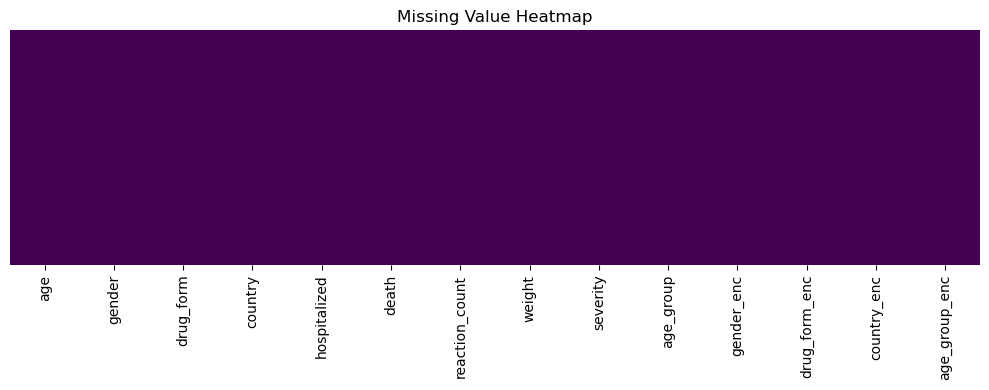

In [6]:
# ---- Plot 1: Missing Value Heatmap ----
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.savefig('eda_01_missing_heatmap.png'); plt.show()
# Observation: Most columns are complete; weight had some missing values (now filled)

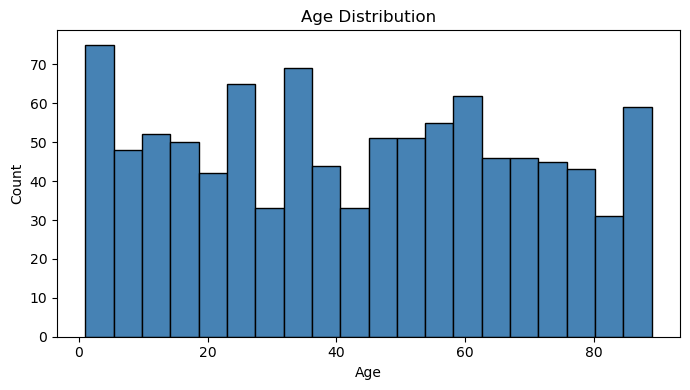

In [7]:
# ---- Plot 2: Age Distribution ----
plt.figure(figsize=(7, 4))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_02_age_dist.png'); plt.show()
# Observation: Ages are uniformly distributed between 1-90

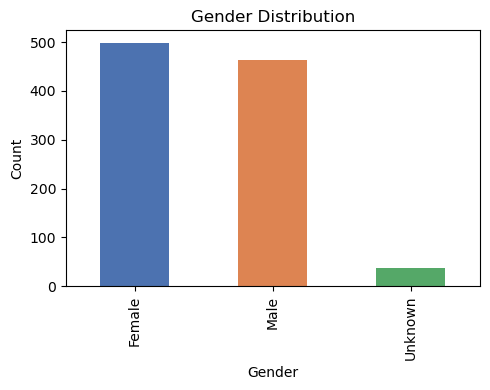

In [8]:
# ---- Plot 3: Gender Distribution ----
plt.figure(figsize=(5, 4))
df['gender'].value_counts().plot(kind='bar', color=['#4c72b0','#dd8452','#55a868'])
plt.title('Gender Distribution')
plt.xlabel('Gender'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_03_gender.png'); plt.show()
# Observation: Male and Female are roughly equal; Unknown is small minority

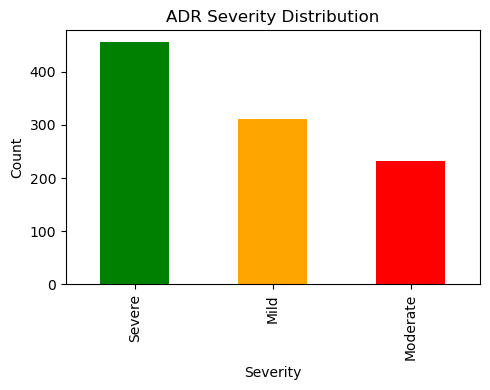

In [9]:
# ---- Plot 4: ADR Severity Distribution ----
plt.figure(figsize=(5, 4))
labels = {0: 'Mild', 1: 'Moderate', 2: 'Severe'}
df['severity'].map(labels).value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('ADR Severity Distribution')
plt.xlabel('Severity'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_04_severity.png'); plt.show()
# Observation: Dataset is imbalanced - Severe and Mild cases dominate

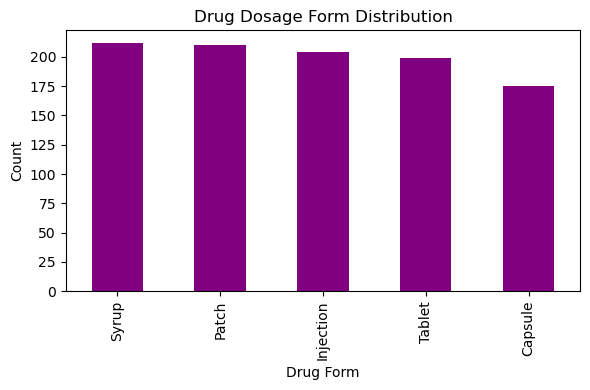

In [10]:
# ---- Plot 5: Drug Dosage Form Distribution ----
plt.figure(figsize=(6, 4))
df['drug_form'].value_counts().plot(kind='bar', color='purple')
plt.title('Drug Dosage Form Distribution')
plt.xlabel('Drug Form'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_05_drugform.png'); plt.show()
# Observation: All forms are roughly equally distributed

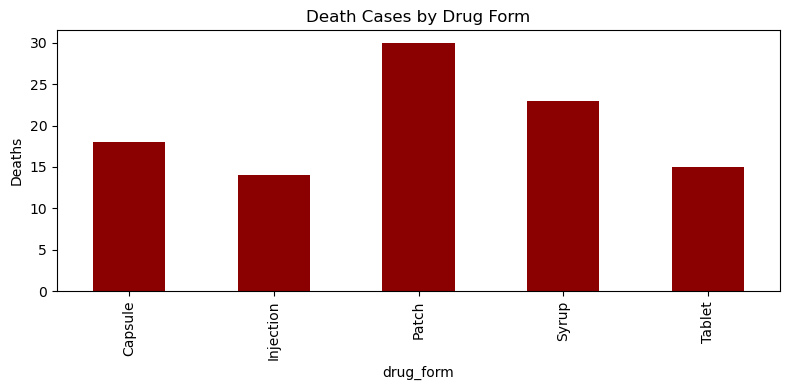

In [11]:
# ---- Plot 8: Death Cases by Drug Form ----
plt.figure(figsize=(8, 4))
death_by_drug = df.groupby('drug_form')['death'].sum()
death_by_drug.plot(kind='bar', color='darkred')
plt.title('Death Cases by Drug Form')
plt.ylabel('Deaths')
plt.tight_layout()
plt.savefig('eda_08_death_drug.png'); plt.show()
# Observation: Injection has relatively more death reports

PART 5: FEATURE ENGINEERING

In [12]:
# Select features and target
features = ['age', 'gender_enc', 'drug_form_enc', 'country_enc',
            'hospitalized', 'death', 'reaction_count', 'weight', 'age_group_enc']

X = df[features]
y = df['severity']

print("Selected features:", features)
print("Target classes:", y.unique())
print("Class distribution:\n", y.value_counts())

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

"""
Feature Selection Justification:
- hospitalized, death: directly indicate severity
- reaction_count: more reactions = more severe
- age, age_group: older patients may react worse
- gender, drug_form, country: demographic/drug factors
- weight: affects drug metabolism
"""

Selected features: ['age', 'gender_enc', 'drug_form_enc', 'country_enc', 'hospitalized', 'death', 'reaction_count', 'weight', 'age_group_enc']
Target classes: [2 0 1]
Class distribution:
 severity
2    455
0    312
1    233
Name: count, dtype: int64

Training samples: 800, Test samples: 200


'\nFeature Selection Justification:\n- hospitalized, death: directly indicate severity\n- reaction_count: more reactions = more severe\n- age, age_group: older patients may react worse\n- gender, drug_form, country: demographic/drug factors\n- weight: affects drug metabolism\n'

PART 6: DECISION TREE MODEL

Accuracy: 1.0
Tree Depth: 3
Number of Leaf Nodes: 5


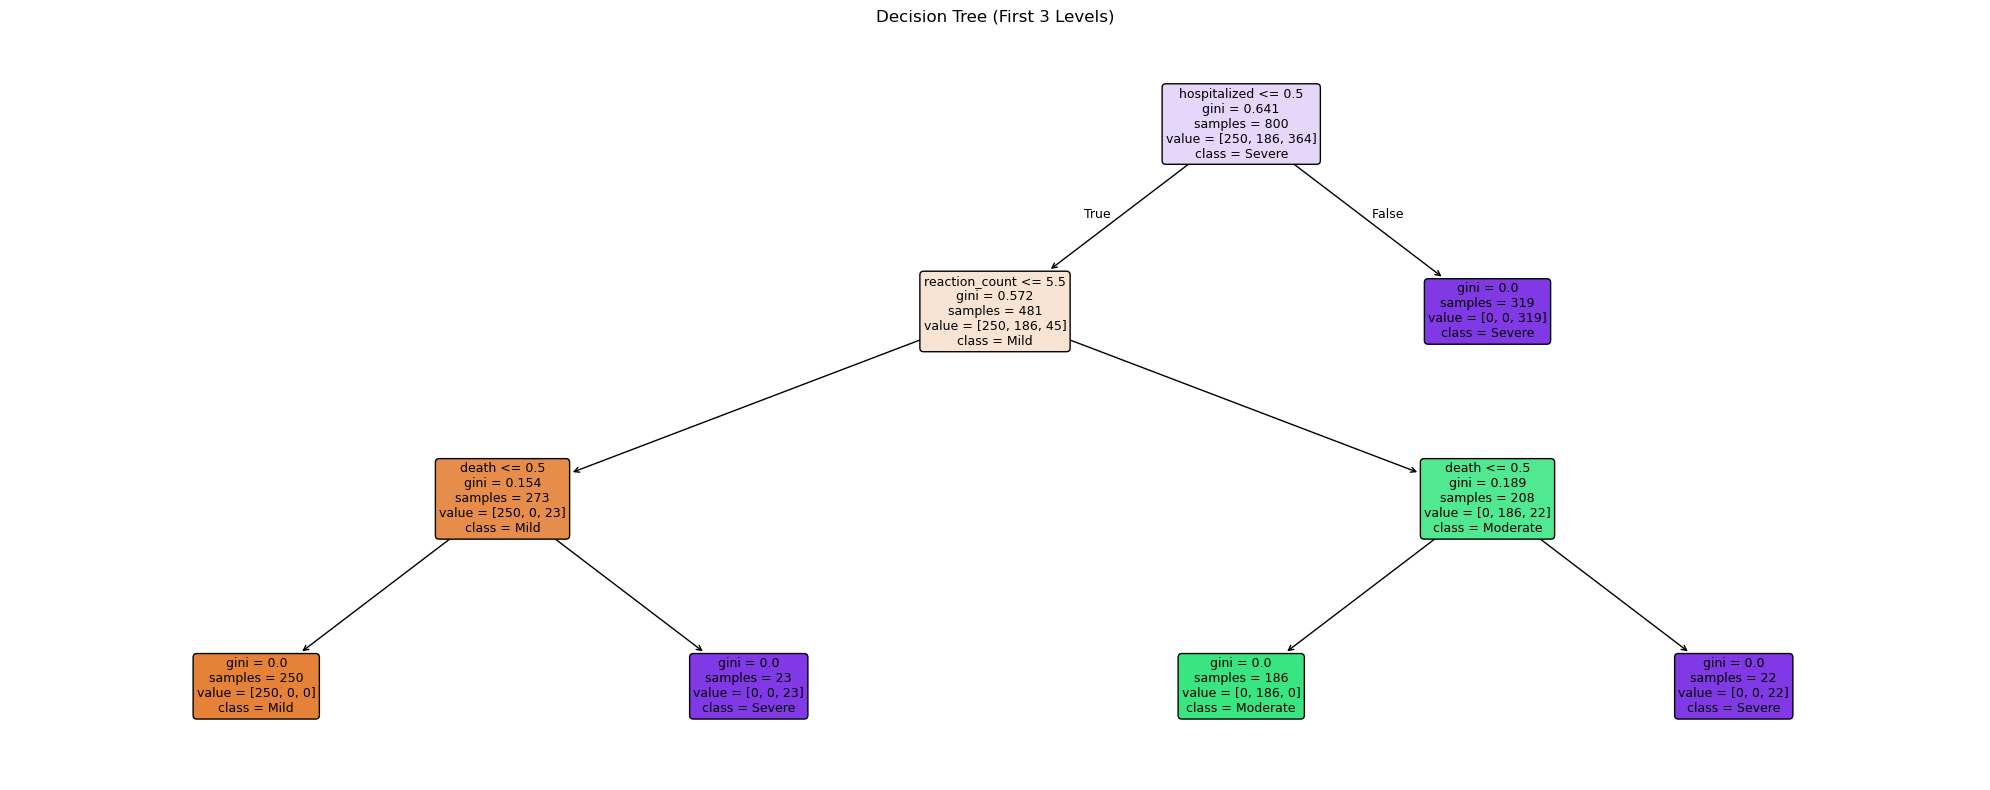

Tree saved as dt_tree_viz.png


In [13]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Tree Depth:", dt.get_depth())
print("Number of Leaf Nodes:", dt.get_n_leaves())

# Visualize the tree (limited depth for readability)
plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=features,
          class_names=['Mild','Moderate','Severe'],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (First 3 Levels)")
plt.tight_layout()
plt.savefig('dt_tree_viz.png'); plt.show()
print("Tree saved as dt_tree_viz.png")


PART 7: HYPERPARAMETER TUNING WITH GridSearchCV

In [14]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", round(grid_search.best_score_, 4))

best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)

print("\n--- Before Tuning ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("--- After Tuning ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Best CV Score: 1.0

--- Before Tuning ---
Accuracy: 1.0
--- After Tuning ---
Accuracy: 1.0


PART 8: MODEL EVALUATION


--- Default Decision Tree ---
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00        62
    Moderate       1.00      1.00      1.00        47
      Severe       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- Tuned Decision Tree ---
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00        62
    Moderate       1.00      1.00      1.00        47
      Severe       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



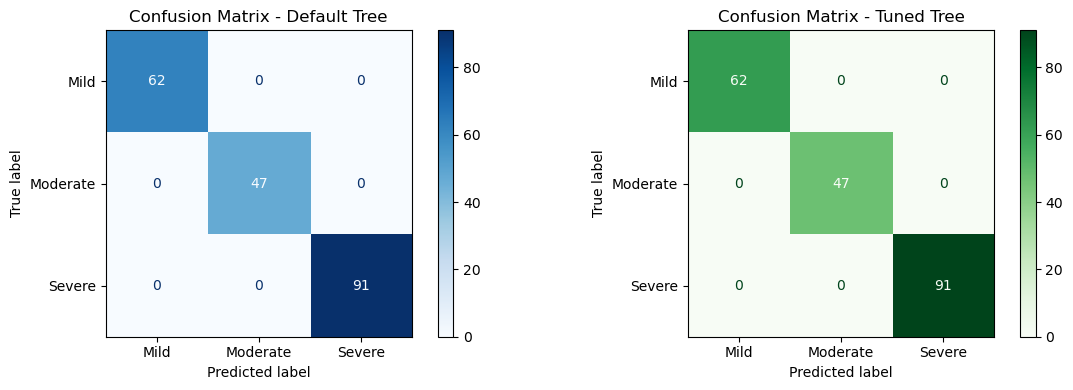

'\nWhy F1-Score is useful for imbalanced datasets:\n- Accuracy can be misleading when one class dominates.\n  Example: If 90% is "Severe", a dumb model that always predicts\n  "Severe" gets 90% accuracy but fails for Mild/Moderate.\n- F1-Score balances Precision and Recall, giving a fair measure\n  across all classes, especially important in medical predictions\n  where missing a case (low recall) can be dangerous.\n'

In [ ]:
print("\n--- Default Decision Tree ---")
print(classification_report(y_test, y_pred, target_names=['Mild','Moderate','Severe']))

print("\n--- Tuned Decision Tree ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Mild','Moderate','Severe']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm1 = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm1, display_labels=['Mild','Moderate','Severe']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix - Default Tree")

cm2 = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm2, display_labels=['Mild','Moderate','Severe']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title("Confusion Matrix - Tuned Tree")

plt.tight_layout()
plt.savefig('evaluation_cm.png'); plt.show()

"""

PART 9: FEATURE IMPORTANCE

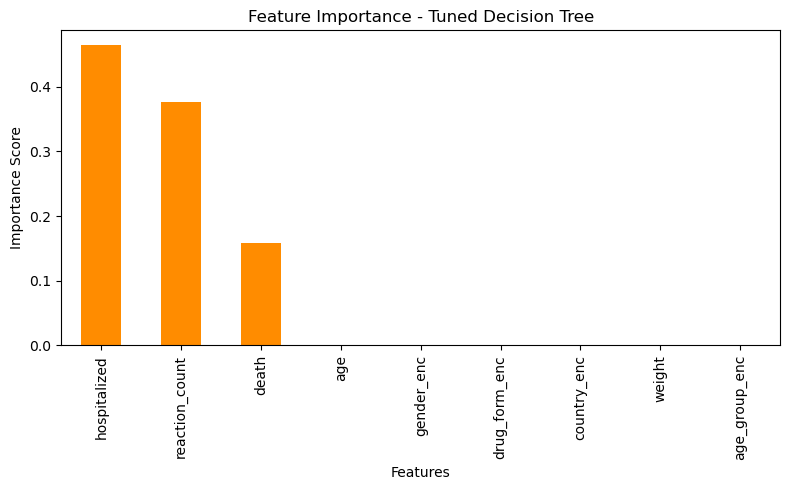

Feature Importances:
hospitalized      0.464090
reaction_count    0.377101
death             0.158809
age               0.000000
gender_enc        0.000000
drug_form_enc     0.000000
country_enc       0.000000
weight            0.000000
age_group_enc     0.000000
dtype: float64


In [16]:
importances = best_dt.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='darkorange')
plt.title('Feature Importance - Tuned Decision Tree')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png'); plt.show()

print("Feature Importances:")
print(feat_imp)

PART 10: INTERPRETATION

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                  Model  Accuracy
Decision Tree (Default)       1.0
  Decision Tree (Tuned)       1.0
    Logistic Regression       1.0
          Random Forest       1.0


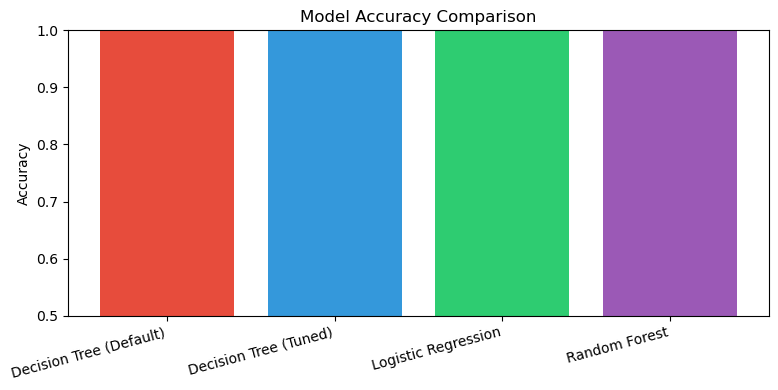

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results = pd.DataFrame({
    'Model': ['Decision Tree (Default)', 'Decision Tree (Tuned)',
              'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred), 4),
        round(accuracy_score(y_test, y_pred_tuned), 4),
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ]
})

print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(results['Model'], results['Accuracy'], color=['#e74c3c','#3498db','#2ecc71','#9b59b6'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('bonus_model_comparison.png'); plt.show()
